In [79]:
import rasterio
from pathlib import Path

TILE_ID = "tile_-345_2244_p1"  # fill in actual tile_id

tile_dir = Path(f"../data/test_tiles/{TILE_ID}")  # fill in actual tile_id

tif_paths = sorted(tile_dir.glob("*/*.tif"))

print(f"{'file':40s} {'crs':25s} {'shape':12s} {'transform'}")
ref = None
for p in tif_paths:
    with rasterio.open(p) as src:
        info = (src.crs, (src.height, src.width), src.transform)
        rel = p.relative_to(tile_dir)
        print(f"{str(rel):40s} {str(info[0]):25s} {str(info[1]):12s} {info[2]}")
        if ref is None:
            ref = info
        else:
            same_crs = info[0] == ref[0]
            same_shape = info[1] == ref[1]
            same_transform = info[2].almost_equals(ref[2], precision=6)
            if not (same_crs and same_shape and same_transform):
                print(f"  !! MISALIGNED vs {tif_paths[0].relative_to(tile_dir)}: "
                      f"crs={same_crs} shape={same_shape} transform={same_transform}")

file                                     crs                       shape        transform
composites/s1s2_2017.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-883200.00|
| 0.00,-10.00, 5747200.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2018.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-883200.00|
| 0.00,-10.00, 5747200.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2019.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-883200.00|
| 0.00,-10.00, 5747200.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2020.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-883200.00|
| 0.00,-10.00, 5747200.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2017.tif                  EPSG:6933                 (256, 256)   | 10.00, 0.00,-883200.00|
| 0.00,-10.00, 5747200.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2018.tif                  EPSG:6933                 (256, 256)   | 10.00, 0.00,-883200.00|
| 0.00,-10.00, 5747200.00|
| 0.00, 0.00

In [80]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import rasterio
from matplotlib.colors import Normalize


PERIOD_YEARS = {
    "p1": range(2017, 2021),
    "p2": range(2020, 2025),
}

period = TILE_ID.rsplit("_", 1)[-1]

if period not in PERIOD_YEARS:
    raise ValueError(f"Unknown period '{period}'")

years = list(PERIOD_YEARS[period])


def read(path, bands=None):
    with rasterio.open(path) as src:
        arr = src.read(bands) if bands else src.read()
        return arr, src.bounds, src.transform


def stretch(arr, low=2, high=98):
    """
    Independent percentile stretch for visualisation only. Fits its own
    bounds from whatever array it's given -- fine for a one-off single
    image, but NOT used for TESSERA/AEE below anymore, since fitting
    per-frame would make color meaning inconsistent across years (see
    fit_stretch_bounds/stretch_fixed).
    """
    out = np.empty_like(arr, dtype="float32")

    for b in range(arr.shape[-1]):
        lo, hi = np.nanpercentile(arr[..., b], [low, high])

        if hi == lo:
            out[..., b] = 0
        else:
            out[..., b] = np.clip(
                (arr[..., b] - lo) / (hi - lo),
                0,
                1,
            )

    return out


def fit_stretch_bounds(arrays, low=2, high=98):
    """
    Fit shared per-band percentile bounds across multiple years' (H, W, C)
    arrays, so every frame in the animation is stretched against the same
    scale -- same principle as gain_norm's fixed 50-100 range below:
    fitting independently per frame would make apparent color/brightness
    shifts across years meaningless, since they could just reflect that
    year's own percentiles shifting rather than any real change in the
    underlying embedding.
    """
    stacked = np.concatenate(
        [a.reshape(-1, a.shape[-1]) for a in arrays],
        axis=0,
    )
    bounds = []
    for b in range(stacked.shape[-1]):
        lo, hi = np.nanpercentile(stacked[:, b], [low, high])
        bounds.append((lo, hi))
    return bounds


def stretch_fixed(arr, bounds):
    """Apply pre-fit per-band bounds (from fit_stretch_bounds) instead of
    refitting percentiles per-frame."""
    out = np.empty_like(arr, dtype="float32")
    for b, (lo, hi) in enumerate(bounds):
        if hi == lo:
            out[..., b] = 0
        else:
            out[..., b] = np.clip((arr[..., b] - lo) / (hi - lo), 0, 1)
    return out


# -----------------------
# Static layers
# -----------------------

slope, _, _ = read(
    tile_dir / "static" / "slope.tif",
    bands=[1],
)

protected, _, _ = read(
    tile_dir / "static" / "protected_area.tif",
    bands=[1],
)

# IMPORTANT:
# This is the continuous gain confidence product.
# Do not threshold it here.
gain_conf, _, _ = read(
    tile_dir / "labels" / "gain_confidence.tif",
    bands=[1],
)

gain_conf = gain_conf[0]

# mask only missing pixels
gain_conf_masked = np.ma.masked_where(
    np.isnan(gain_conf),
    gain_conf,
)

# fixed confidence scale (raw exported range is 50-100, not 0-1)
gain_norm = Normalize(
    vmin=50,
    vmax=100,
)


# -----------------------
# Build frames
# -----------------------

def fixed_stretch(arr, vmin=0, vmax=3000):
    return np.clip((arr - vmin) / (vmax - vmin), 0, 1)


def _db_stretch(band, vmin, vmax):
    return np.clip((band - vmin) / (vmax - vmin), 0, 1)


# First pass: load every year's raw TESSERA/AEE arrays so we can fit one
# shared stretch per embedding source across the whole period, rather
# than letting each year's frame set its own percentiles.
tess_raw = {}
aee_raw = {}

for year in years:
    tess, _, _ = read(
        tile_dir / "embeddings" / f"tessera_{year}.tif",
        bands=[1, 2, 3],
    )
    tess_raw[year] = tess.transpose(1, 2, 0)

    aee, _, _ = read(
        tile_dir / "embeddings" / f"aee_{year}.tif",
        bands=[1, 2, 3],
    )
    aee_raw[year] = aee.transpose(1, 2, 0)

tess_bounds = fit_stretch_bounds(list(tess_raw.values()))
aee_bounds = fit_stretch_bounds(list(aee_raw.values()))


frames = []

for year in years:

    composite = tile_dir / "composites" / f"s1s2_{year}.tif"


    # Sentinel-2 RGB
    s2, _, _ = read(
        composite,
        bands=[3, 2, 1],
    )

    rgb = fixed_stretch(
        s2.transpose(1, 2, 0)
    )


    # NDVI
    ndvi, _, _ = read(
        composite,
        bands=[8],
    )


    # Sentinel-1
    # bands:
    # 10 = VV
    # 11 = VH
    s1, _, _ = read(
        composite,
        bands=[10, 11],
    )

    vv = s1[0]
    vh = s1[1]

    s1_rgb = np.stack(
        [
            _db_stretch(vv, -25, 0),
            _db_stretch(vh, -30, -5),
            _db_stretch(vv - vh, 0, 15),
        ],
        axis=-1,
    )


    # TESSERA -- shared bounds across years, fit once above
    tess_rgb = stretch_fixed(tess_raw[year], tess_bounds)


    # AEE -- shared bounds across years, fit once above
    aee_rgb = stretch_fixed(aee_raw[year], aee_bounds)


    frames.append(
        {
            "year": year,
            "rgb": rgb,
            "ndvi": ndvi[0],
            "s1": s1_rgb,
            "tess": tess_rgb,
            "aee": aee_rgb,
        }
    )


# -----------------------
# Plot
# -----------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

title = fig.suptitle("")


im_rgb = axes[0,0].imshow(
    frames[0]["rgb"]
)
axes[0,0].set_title(
    "Sentinel-2 RGB"
)


im_ndvi = axes[0,1].imshow(
    frames[0]["ndvi"],
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
)
axes[0,1].set_title(
    "NDVI"
)


im_s1 = axes[0,2].imshow(
    frames[0]["s1"]
)
axes[0,2].set_title(
    "Sentinel-1 VV / VH / VV-VH"
)


im_tess = axes[0,3].imshow(
    frames[0]["tess"]
)
axes[0,3].set_title(
    "TESSERA"
)


im_aee = axes[1,0].imshow(
    frames[0]["aee"]
)
axes[1,0].set_title(
    "AEE"
)


axes[1,1].imshow(
    slope[0],
    cmap="viridis",
    vmin=0,
    vmax=max(np.nanmax(slope), 1e-6),
)
axes[1,1].set_title(
    "Slope"
)


axes[1,2].imshow(
    protected[0],
    cmap="Greens",
    vmin=0,
    vmax=1,
)
axes[1,2].set_title(
    "Protected area"
)


# Gain confidence overlay
overlay_rgb = axes[1,3].imshow(
    frames[0]["rgb"]
)

overlay_gain = axes[1,3].imshow(
    gain_conf_masked,
    cmap="plasma",
    norm=gain_norm,
    alpha=0.75,
)

axes[1,3].set_title(
    "Gain confidence"
)

cbar = fig.colorbar(
    overlay_gain,
    ax=axes[1,3],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Tree cover confidence (canopy cover %, year_end)"
)


for ax in axes.flat:
    ax.axis("off")


def update(i):

    f = frames[i]

    title.set_text(
        f"{TILE_ID} — {f['year']}"
    )

    im_rgb.set_data(f["rgb"])
    im_ndvi.set_data(f["ndvi"])
    im_s1.set_data(f["s1"])
    im_tess.set_data(f["tess"])
    im_aee.set_data(f["aee"])

    overlay_rgb.set_data(
        f["rgb"]
    )

    # DO NOT update overlay_gain with a binary mask.
    # The confidence raster is static across years.
    return (
        title,
        im_rgb,
        im_ndvi,
        im_s1,
        im_tess,
        im_aee,
        overlay_rgb,
        overlay_gain,
    )


anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=800,
    blit=False,
)


plt.close(fig)

HTML(anim.to_jshtml())

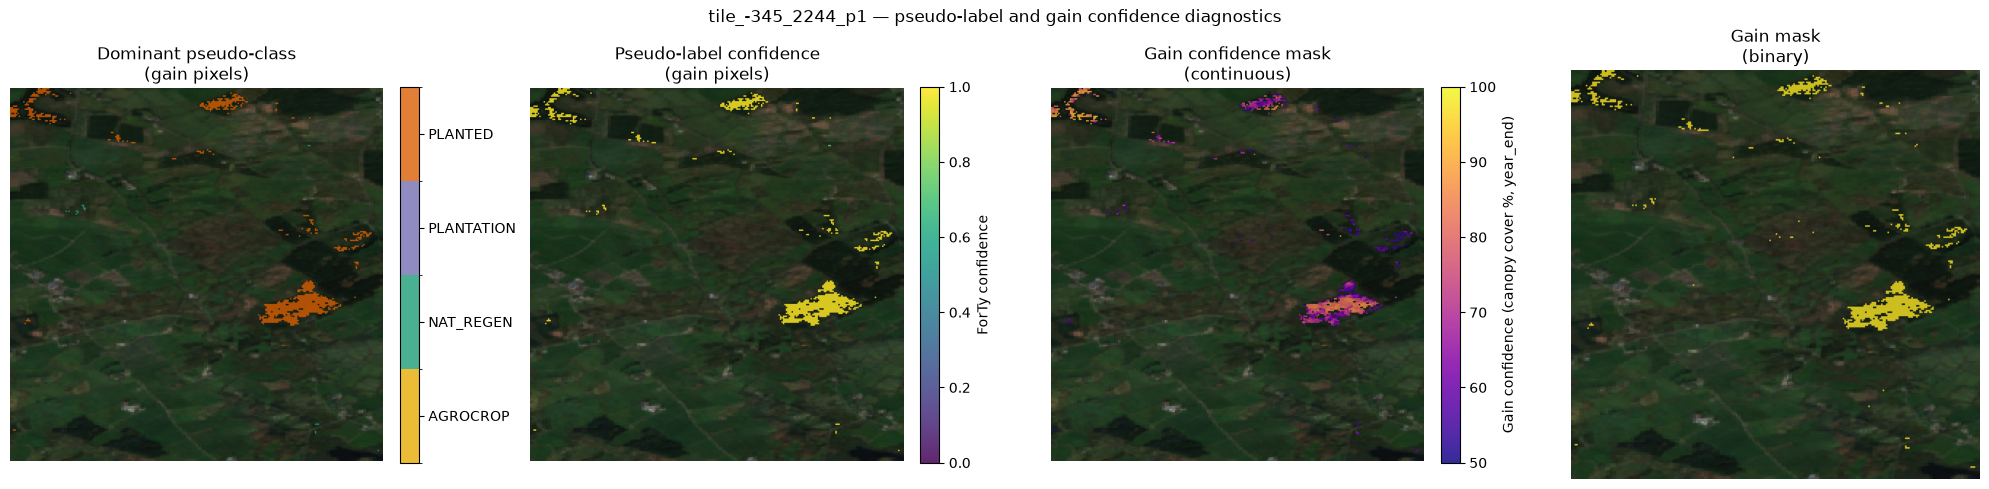

gain pixels: 1183
gain percentage of tile: 1.81%

Pseudo-labelled gain pixels:
  1141 / 1183 (96.4%)

Dominant class distribution:
  NAT_REGEN                20 (  1.8%)
  PLANTED                1121 ( 98.2%)

Gain confidence:
  min:  50.196
  mean: 71.370
  max:  95.294

Pseudo-label confidence:
  min:  0.750
  mean: 1.000
  max:  1.000


In [81]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np

pseudo, _, _ = read(tile_dir / "labels" / "pseudo_labels.tif")

dominant = pseudo[4]      # band 5
confidence = pseudo[5]    # band 6

# Continuous gain confidence
gain_conf, _, _ = read(
    tile_dir / "labels" / "gain_confidence.tif",
    bands=[1],
)
gain_conf = gain_conf[0]

# Binary version derived from confidence (NaN outside coverage, so
# isnan is the correct mask -- gain_conf > 0 happens to work too since
# every valid pixel is >50, but isnan says what's actually meant)
gain_valid = ~np.isnan(gain_conf)
gain_binary = gain_valid

class_names = [
    "AGROCROP",
    "NAT_REGEN",
    "PLANTATION",
    "PLANTED",
]

class_colors = [
    "#e6ab02",
    "#1b9e77",
    "#7570b3",
    "#d95f02",
]

cmap_classes = ListedColormap(class_colors)

norm_classes = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap_classes.N,
)

comp_2020, _, _ = read(
    tile_dir / "composites" / "s1s2_2020.tif",
    bands=[3, 2, 1],
)

rgb_2020 = fixed_stretch(
    comp_2020.transpose(1, 2, 0)
)

fig2, axes2 = plt.subplots(
    1,
    4,
    figsize=(20, 5),
)

fig2.suptitle(
    f"{TILE_ID} — pseudo-label and gain confidence diagnostics"
)

axes2[0].imshow(rgb_2020)

dom_masked = np.ma.masked_where(
    ~gain_binary | (dominant == -9999),
    dominant,
)

im0 = axes2[0].imshow(
    dom_masked,
    cmap=cmap_classes,
    norm=norm_classes,
    alpha=0.8,
)

axes2[0].set_title(
    "Dominant pseudo-class\n(gain pixels)"
)

cbar = fig2.colorbar(
    im0,
    ax=axes2[0],
    ticks=[0, 1, 2, 3],
    fraction=0.046,
    pad=0.04,
)

cbar.ax.set_yticklabels(class_names)

axes2[1].imshow(rgb_2020)

conf_masked = np.ma.masked_where(
    ~gain_binary | (confidence == -9999),
    confidence,
)

im1 = axes2[1].imshow(
    conf_masked,
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.85,
)

axes2[1].set_title(
    "Pseudo-label confidence\n(gain pixels)"
)

cbar = fig2.colorbar(
    im1,
    ax=axes2[1],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "ForTy confidence"
)

axes2[2].imshow(rgb_2020)

gain_masked = np.ma.masked_where(
    ~gain_valid,
    gain_conf,
)

# Fixed 50-100 scale -- matches the first animation cell, and matches
# gain_confidence.tif's real physical range (every validated pixel is
# canopy-cover % at year_end, which is always >TREE_THRESHOLD=50 by
# construction). Using np.nanmax(gain_conf) here instead would rescale
# each tile independently, making tiles visually incomparable and
# inconsistent with the other diagnostic cell.
im2 = axes2[2].imshow(
    gain_masked,
    cmap="plasma",
    vmin=50,
    vmax=100,
    alpha=0.85,
)

axes2[2].set_title(
    "Gain confidence mask\n(continuous)"
)

cbar = fig2.colorbar(
    im2,
    ax=axes2[2],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Gain confidence (canopy cover %, year_end)"
)

axes2[3].imshow(rgb_2020)

im3 = axes2[3].imshow(
    np.ma.masked_where(
        ~gain_binary,
        gain_binary,
    ),
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.8,
)

axes2[3].set_title(
    "Gain mask\n(binary)"
)


for ax in axes2:
    ax.axis("off")


plt.tight_layout()
plt.show()

n_gain = int(gain_binary.sum())

print(
    f"gain pixels: {n_gain}"
)

print(
    f"gain percentage of tile: "
    f"{100*n_gain/gain_binary.size:.2f}%"
)


if n_gain > 0:
    labelled = (dominant != -9999) & (confidence != -9999)

    pseudo_valid = (
        gain_binary &
        labelled &
        np.isfinite(dominant) &
        np.isfinite(confidence)
    )

    gain_dominant = dominant[pseudo_valid]
    gain_label_conf = confidence[pseudo_valid]
    gain_conf_values = gain_conf[gain_binary]

    print("\nPseudo-labelled gain pixels:")
    print(f"  {pseudo_valid.sum()} / {n_gain} ({100 * pseudo_valid.sum() / n_gain:.1f}%)")

    counts = np.bincount(
        gain_dominant.astype(np.int32),
        minlength=len(class_names),
    )

    print("\nDominant class distribution:")

    for c, n in enumerate(counts):
        if n:
            print(f"  {class_names[c]:20s} {n:6d} ({100*n/gain_dominant.size:5.1f}%)")

    print("\nGain confidence:")
    print(f"  min:  {np.nanmin(gain_conf_values):.3f}")
    print(f"  mean: {np.nanmean(gain_conf_values):.3f}")
    print(f"  max:  {np.nanmax(gain_conf_values):.3f}")

    print("\nPseudo-label confidence:")
    print(f"  min:  {np.nanmin(gain_label_conf):.3f}")
    print(f"  mean: {np.nanmean(gain_label_conf):.3f}")
    print(f"  max:  {np.nanmax(gain_label_conf):.3f}")

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from ipywidgets import interact, Dropdown


PERIOD_YEARS = {
    "p1": range(2017, 2021),
    "p2": range(2020, 2025),
}


period = TILE_ID.rsplit("_", 1)[-1]

if period not in PERIOD_YEARS:
    raise ValueError(
        f"Unknown period '{period}'. Expected p1 or p2."
    )


years = list(PERIOD_YEARS[period])


embedding_data = {
    "AEE": {},
    "TESSERA": {}
}


for model in embedding_data:

    for year in years:

        path = (
            tile_dir
            / "embeddings"
            / f"{model.lower()}_{year}.tif"
        )

        with rasterio.open(path) as src:
            arr = src.read()

        embedding_data[model][year] = arr.astype("float32")


def z_normalise_embedding(arr, clip=3):

    output = np.zeros_like(
        arr,
        dtype="float32"
    )

    for dim in range(arr.shape[0]):

        band = arr[dim]

        mean = np.nanmean(band)
        std = np.nanstd(band)

        if std == 0 or np.isnan(std):
            output[dim] = 0

        else:
            output[dim] = np.clip(
                (band - mean) / std,
                -clip,
                clip
            )

    return output


embedding_z = {
    model: {
        year: z_normalise_embedding(arr)
        for year, arr in data.items()
    }
    for model, data in embedding_data.items()
}


def plot_embedding_dimensions(model, year):

    embedding = embedding_z[model][year]

    n_dims = embedding.shape[0]

    cols = 4
    rows = int(np.ceil(n_dims / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, rows * 2.1),
        constrained_layout=False
    )

    axes = np.asarray(axes).ravel()

    im = None

    for dim, ax in enumerate(axes):

        if dim < n_dims:

            im = ax.imshow(
                embedding[dim],
                cmap="coolwarm",
                vmin=-3,
                vmax=3,
                interpolation="nearest"
            )

            ax.set_title(
                f"Dimension {dim + 1}",
                fontsize=8,
                pad=2
            )

            ax.set_xticks([])
            ax.set_yticks([])

        else:

            ax.set_visible(False)

    fig.suptitle(
        f"{TILE_ID} — {model} embedding dimensions ({year})",
        fontsize=16,
        y=0.992
    )

    fig.subplots_adjust(
        left=0.03,
        right=0.90,
        top=0.98,
        bottom=0.02,
        wspace=0.08,
        hspace=0.30
    )

    cax = fig.add_axes(
        [
            0.92,
            0.25,
            0.015,
            0.5
        ]
    )

    cbar = fig.colorbar(
        im,
        cax=cax
    )

    cbar.set_label(
        "Z-normalised activation",
        rotation=270,
        labelpad=15
    )

    plt.show()


interact(
    plot_embedding_dimensions,
    model=Dropdown(
        options=[
            "AEE",
            "TESSERA"
        ],
        value="AEE",
        description="Embedding:"
    ),
    year=Dropdown(
        options=years,
        value=years[0],
        description="Year:"
    )
)

interactive(children=(Dropdown(description='Embedding:', options=('AEE', 'TESSERA'), value='AEE'), Dropdown(de…

<function __main__.plot_embedding_dimensions(model, year)>

In [ ]:
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from ipywidgets import (
    interact,
    Dropdown,
    Output,
    HBox
)

from ipydatagrid import DataGrid



def z_normalise_band(band, clip=3):

    mean = np.nanmean(band)
    std = np.nanstd(band)

    if std == 0 or np.isnan(std):
        return np.zeros_like(
            band,
            dtype="float32"
        )

    return np.clip(
        (band - mean) / std,
        -clip,
        clip
    )



def load_embedding_analysis(model, year):

    with rasterio.open(
        tile_dir / "embeddings" / f"{model.lower()}_{year}.tif"
    ) as src:

        embedding = src.read().astype("float32")


    embedding_z = np.stack(
        [
            z_normalise_band(embedding[i])
            for i in range(embedding.shape[0])
        ]
    )


    with rasterio.open(
        tile_dir / "labels" / "gain_confidence.tif"
    ) as src:

        gain = src.read(1)


    gain_mask = gain > 50


    results = []

    for dim in range(embedding.shape[0]):

        gain_values = embedding[dim][gain_mask]
        nongain_values = embedding[dim][~gain_mask]


        difference = (
            np.nanmean(gain_values)
            -
            np.nanmean(nongain_values)
        )


        pooled_std = np.sqrt(
            (
                np.nanvar(gain_values)
                +
                np.nanvar(nongain_values)
            ) / 2
        )


        results.append(
            {
                "dimension": dim + 1,
                "gain_mean": np.nanmean(gain_values),
                "nongain_mean": np.nanmean(nongain_values),
                "difference": difference,
                "effect_size": (
                    difference / pooled_std
                    if pooled_std != 0
                    else 0
                )
            }
        )


    df = pd.DataFrame(results)


    df = (
        df[
            (df["difference"] > 0)
            &
            (df["gain_mean"] > 0)
        ]
        .sort_values(
            "effect_size",
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )


    return embedding_z, gain_mask, df



def embedding_viewer(model, year):

    embedding, gain_mask, df = load_embedding_analysis(
        model,
        year
    )


    output = Output()


    grid = DataGrid(
        df,
        selection_mode="row",
        layout={
            "height": "350px",
            "width": "850px"
        },
        base_row_size=32,
        base_column_size=130
    )


    def get_selected_dimension():

        try:

            selections = grid.selections

            if len(selections) > 0:

                row = selections[0]["r1"]

                return int(
                    df.iloc[row]["dimension"]
                )

        except Exception:
            pass


        return int(
            df.iloc[0]["dimension"]
        )



    def plot_dimension(*args):

        dim = get_selected_dimension()


        with output:

            output.clear_output(
                wait=True
            )


            fig, ax = plt.subplots(
                figsize=(7,7)
            )


            im = ax.imshow(
                embedding[dim-1],
                cmap="coolwarm",
                vmin=-3,
                vmax=3
            )


            # gain mask overlay
            ax.imshow(
                np.ma.masked_where(
                    ~gain_mask,
                    gain_mask
                ),
                cmap="viridis",
                alpha=0.5
            )


            ax.set_title(
                f"{model} {year} — dimension {dim}",
                fontsize=14
            )

            ax.axis("off")


            cbar = fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.04
            )

            cbar.set_label(
                "Z-normalised activation",
                rotation=270,
                labelpad=15
            )


            plt.tight_layout()

            plt.show()



    grid.observe(
        plot_dimension,
        names=[
            "selections"
        ]
    )


    display(
        HBox(
            [
                grid,
                output
            ]
        )
    )


    plot_dimension()


interact(
    embedding_viewer,

    model=Dropdown(
        options=[
            "AEE",
            "TESSERA"
        ],
        value="AEE",
        description="Embedding:"
    ),

    year=Dropdown(
        options=years,
        value=years[-1],
        description="Year:"
    )
);

interactive(children=(Dropdown(description='Embedding:', options=('AEE', 'TESSERA'), value='AEE'), Dropdown(de…

In [84]:
import ee
from config import settings
from gee.auth import get_ee_credentials
from tiling.grid import tile_geom
from registry.store import load_registry_entry

ee.Initialize(get_ee_credentials(), project=settings.gee_project)

tile = load_registry_entry(TILE_ID)
if tile is None:
    raise ValueError(f"No registry entry for {TILE_ID}")

geom = tile_geom(tile)  # exact export geometry, EPSG:6933

print("EASE-Grid (meters):", tile["x_min_m"], tile["y_min_m"], tile["x_max_m"], tile["y_max_m"])
print("Lon/lat bbox:      ", tile["min_lon"], tile["min_lat"], tile["max_lon"], tile["max_lat"])

centroid = geom.centroid(maxError=1).coordinates().getInfo()
print("Centroid lon/lat:  ", centroid)

EASE-Grid (meters): -883200.0 5744640.0 -880640.0 5747200.0
Lon/lat bbox:       -9.153633010863153 51.606791891418965 -9.127100741266448 51.63884888299188
Centroid lon/lat:   [-9.140366876053871, 51.622819252176164]


In [85]:
lon, lat = centroid
zoom = 15  # ~2.56km tile is comfortably visible around z14-16
url = f"https://code.earthengine.google.com/?lat={lat}&lon={lon}&zoom={zoom}"
print(url)

https://code.earthengine.google.com/?lat=51.622819252176164&lon=-9.140366876053871&zoom=15


In [86]:
import geemap
from export.composites import s2_composite

Map = geemap.Map(center=[lat, lon], zoom=15)
Map.addLayer(geom, {"color": "red"}, "tile boundary")

for year in settings.period_years:
    comp = s2_composite(geom, year)
    Map.addLayer(
        comp.select(["B4", "B3", "B2"]),
        {"min": 0, "max": 3000},
        f"S2 composite {year}",
    )

Map

Map(center=[51.622819252176164, -9.140366876053871], controls=(WidgetControl(options=['position', 'transparent…